In [1]:
import pandas as pd

url = "/Users/suheylatozan/Desktop/Movement Recovery Lab/sc_ramp.csv"
df = pd.read_csv(url)

import sys, os
sys.path.append("/Users/suheylatozan/Desktop/hbmep/src")

In [2]:
df.shape

(1295, 38)

In [3]:
idx = (df.participant == "s109") & (df.recr_curve == "scramp-002")
temp_df = df[idx].reset_index(drop=True).copy()

<Axes: xlabel='sc_current', ylabel='FCR'>

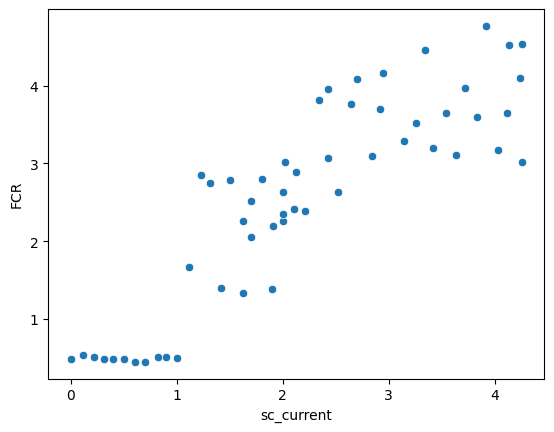

In [4]:
import seaborn as sns

sns.scatterplot(x=temp_df["sc_current"], y=temp_df["FCR"])

In [5]:
df

,mode,recr_curve,sc_current,cx_voltage,datalength,sweep,timestamp,timestamp_s,timestamp_ms,Fs,...,LFCR,LAPB,LADM,RDeltoid,ssep_size,hue_ADM,hue_APB,hue_ECR,hue_FCR,hue_Triceps
0,research_paired_repeat,scramp-001,0.000000,72.064078,901,0.15,63136155930000,63136155.93,63136155930,6006.666667,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
1,research_paired_repeat,scramp-001,0.000000,73.240733,901,0.15,63136157930000,63136157.93,63136157930,6006.666667,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2,research_paired_repeat,scramp-001,0.000000,72.946569,901,0.15,63136159930000,63136159.93,63136159930,6006.666667,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
3,research_paired_repeat,scramp-001,0.000000,72.064274,901,0.15,63136167350000,63136167.35,63136167350,6006.666667,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
4,research_paired_repeat,scramp-001,0.000000,72.946374,901,0.15,63136169350000,63136169.35,63136169350,6006.666667,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1290,research_paired_repeat,scramp-006,4.731587,51.207570,901,0.15,63141690920000,63141690.92,63141690920,6006.666667,...,NaN,NaN,NaN,243.677947,901.0,0,0,0,0,0
1291,research_paired_repeat,scramp-006,4.731587,51.207570,901,0.15,63141692920000,63141692.92,63141692920,6006.666667,...,NaN,NaN,NaN,254.469659,901.0,0,0,0,0,0
1292,research_paired_repeat,scramp-006,4.731587,51.207570,901,0.15,63141694920000,63141694.92,63141694920,6006.666667,...,NaN,NaN,NaN,223.144381,901.0,0,0,0,0,0
1293,research_paired_repeat,scramp-006,4.731587,51.207570,901,0.15,63141696920000,63141696.92,63141696920,6006.666667,...,NaN,NaN,NaN,284.652321,901.0,0,0,0,0,0


In [6]:
import os

current_directory = os.getcwd()
output_path = os.path.join(current_directory, "paired_dataset.pdf")

# Plot dataset and save it as a PDF
# model.plot(df, output_path=output_path)

In [7]:
# ============================================
# Imports
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import jax
import jax.numpy as jnp
import numpyro as pyro
import numpyro.distributions as dist

# Disable JAX warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")


/Users/suheylatozan/Desktop/Movement Recovery Lab/hbmep/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import logging

import numpy as np
import jax
import jax.numpy as jnp
import numpyro as pyro
import numpyro.distributions as dist

from hbmep import functional as F, smooth_functional as SF
from hbmep.model import BaseModel
from hbmep.util import site

EPS = 1e-3


class HB(BaseModel):
    def __init__(self, *args, **kw):
        super(HB, self).__init__(*args, **kw)
        self.use_mixture = False

    def hb_rl(self, intensity, features, response=None, **kw):
        num_data = intensity.shape[0]
        num_features = np.max(features, axis=0) + 1

        # Mask missing observations
        mask_obs = True
        if response is not None:
            mask_obs = np.invert(np.isnan(response))

        # Hyper-priors
        a_loc = pyro.sample(
            site.a.log, dist.TruncatedNormal(5., 10., low=0)
        )
        a_scale = pyro.sample(site.a.scale, dist.HalfNormal(10.))
        b_scale = pyro.sample(site.b.scale, dist.HalfNormal(10.))
        h_scale = pyro.sample(site.h.scale, dist.HalfNormal(50.))

        g_scale = pyro.sample(site.g.scale, dist.HalfNormal(5.))
        v_scale = pyro.sample(site.v.scale, dist.HalfNormal(1.))

        c1_scale = pyro.sample(site.c1.scale, dist.HalfNormal(5.))
        c2_scale = pyro.sample(site.c2.scale, dist.HalfNormal(.5))

        # Priors
        with pyro.plate(site.num_response, self.num_response):
            with pyro.plate_stack(
                site.num_features, num_features, rightmost_dim=-2
            ):
                a = pyro.sample(
                    site.a, dist.TruncatedNormal(a_loc, a_scale, low=0)
                )

                b_raw = pyro.sample(site.b.raw, dist.HalfNormal(1))
                b = pyro.deterministic(site.b, b_scale * b_raw)

                g_raw = pyro.sample(site.g.raw, dist.HalfNormal(1))
                g = pyro.deterministic(site.g, g_scale * g_raw)

                h_raw = pyro.sample(site.h.raw, dist.HalfNormal(1))
                h = pyro.deterministic(site.h, h_scale * h_raw)

                v_raw = pyro.sample(site.v.raw, dist.HalfNormal(1))
                v = pyro.deterministic(site.v, v_scale * v_raw)

                c1_raw = pyro.sample(site.c1.raw, dist.HalfNormal(1))
                c1 = pyro.deterministic(site.c1, c1_scale * c1_raw)

                c2_raw = pyro.sample(site.c2.raw, dist.HalfNormal(1))
                c2 = pyro.deterministic(site.c2, c2_scale * c2_raw)

        # Outlier probability
        if self.use_mixture:
            q = pyro.sample(site.outlier_prob, dist.Uniform(0., 0.01))

        # Observation model
        with pyro.handlers.mask(mask=mask_obs):
            with pyro.plate(site.num_response, self.num_response):
                with pyro.plate(site.num_data, num_data):
                    mu, alpha, beta = self.gamma_likelihood(
                        SF.rectified_logistic,
                        intensity,
                        (
                            a[*features.T],
                            b[*features.T],
                            g[*features.T],
                            h[*features.T],
                            v[*features.T],
                            EPS,
                        ),
                        c1[*features.T],
                        c2[*features.T],
                    )
                    pyro.deterministic(site.mu, mu)

                    # Mixture distribution
                    if self.use_mixture:
                        mixing_distribution = dist.Categorical(
                            probs=jnp.stack([1 - q, q], axis=-1)
                        )
                        component_distributions=[
                            dist.Gamma(concentration=alpha, rate=beta),
                            dist.HalfNormal(
                                scale=(g[*features.T] + h[*features.T])
                            )
                        ]
                        Mixture = dist.MixtureGeneral(
                            mixing_distribution=mixing_distribution,
                            component_distributions=component_distributions
                        )

                    # Observations
                    y_ = pyro.sample(
                        site.obs,
                        (
                            Mixture if self.use_mixture
                            else dist.Gamma(concentration=alpha, rate=beta)
                        ),
                        obs=response
                    )


In [9]:
# ============================================
# Least Squares Recruitment Curve Optimization
# ============================================

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def rectified_logistic_scaled(x01, a, b, g, h):
    return g + h * sigmoid(b * (x01 - a))

def rectified_logistic(x01, a, b, g, h, v):
    # v controls sharpness
    return g + max(0, (-v + (h+v)*sigmoid(b*(x01-a)-np.log(h/v))))


def scale_minmax(x):
    xmin, xmax = float(np.min(x)), float(np.max(x))
    rng = xmax - xmin if xmax > xmin else 1.0
    return (x - xmin) / rng, xmin, rng

def fit_rectified_logistic(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 5:
        raise ValueError("Need at least 5 points")
    x01, xmin, xrng = scale_minmax(x)
    g0 = np.percentile(y, 10.0)
    u0 = np.percentile(y, 90.0)
    h0 = max(u0 - g0, 1e-6)
    a0, b0, v0 = 0.5, 5.0, 1.0
    p0 = np.array([a0, b0, g0, h0, v0], float)
    lb = np.array([1e-4, 1e-4, 1e-4, 1e-4, 1e-4])
    ub = np.array([5.0, 200.0, 2.0, 1000.0, 10.0]) # Look into parameters - Desmos

    def residuals(theta):
        a, b, g, h, v = theta
        mu = rectified_logistic(x01, a, b, g, h, v)
        return mu - y

    res = least_squares(residuals, p0, bounds=(lb, ub),
                        loss="soft_l1", f_scale=1.0, max_nfev=20000)
    a, b, g, h, v = res.x
    mu = rectified_logistic(x01, a, b, g, h, v)
    rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
    ss_res = np.sum((y - mu)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {"params": dict(a=a,b=b,g=g,h=h,v=v, xmin=xmin,xrng=xrng),
            "rmse": rmse, "r2": r2, "success": bool(res.success)}

def predict_ls_curve(x_new, fit):
    p = fit["params"]
    x01 = (np.asarray(x_new) - p["xmin"]) / (p["xrng"] if p["xrng"] != 0 else 1.0)
    return rectified_logistic(x01, p["a"], p["b"], p["g"], p["h"], p["v"])



In [10]:
csv_path = "/Users/suheylatozan/Desktop/Movement Recovery Lab/sc_ramp.csv"
df = pd.read_csv(csv_path)
req_cols = ["sc_current", "FCR", "participant", "recr_curve"]
df = df.dropna(subset=req_cols).copy()

group_cols = ["participant", "recr_curve"]


In [11]:
#Run hbMEP Bayesian Model

model = HB()
model.intensity = "sc_current"
model.features = group_cols
model.response = ["FCR"]
model._model = model.hb_rl
model.use_mixture = True
model.mcmc_params = dict(num_chains=2, num_warmup=500, num_samples=250)

# Encode and run
df_enc, enc = model.load(df)
mcmc, posterior = model.run(df=df_enc)
pred_df = model.make_prediction_dataset(df=df_enc, num_points=200)
predictive = model.predict(df=pred_df, posterior=posterior, num_samples=500, return_sites=[site.mu])
pred_df["mu_post_mean"] = np.asarray(predictive[site.mu]).mean(axis=0)


TypeError: BaseModel.gamma_likelihood() takes 3 positional arguments but 5 were given

In [ ]:
# --- Decode categorical features using LabelEncoder objects ---
for col in model.features:
    if col in pred_df and col in enc:
        le = enc[col]  # this is a LabelEncoder
        if hasattr(le, "classes_"):
            pred_df[col] = le.inverse_transform(pred_df[col].astype(int))

print("Decoded participants in pred_df:", pred_df["participant"].unique())
print("Decoded recr_curve in pred_df:", pred_df["recr_curve"].unique())


Decoded participants in pred_df: ['s101' 's109' 's114' 's118']
Decoded recr_curve in pred_df: ['scramp-001' 'scramp-002' 'scramp-003' 'scramp-004' 'scramp-005'
 'scramp-006' 'scramp-007' 'scramp-008' 'scramp-009']


In [18]:
# ============================================
# Helper: Fit least-squares curve for each participant/recruitment curve group
# ============================================

def fit_by_group_ls(df, intensity_col, response_col, group_cols):
    rows = []
    for combo, gdf in df.groupby(group_cols):
        combo = combo if isinstance(combo, tuple) else (combo,)
        try:
            fit = fit_rectified_logistic(
                gdf[intensity_col].values,
                gdf[response_col].values
            )
            row = {c: v for c, v in zip(group_cols, combo)}
            row.update(fit["params"])
            row.update(dict(
                success=fit["success"],
                rmse=fit["rmse"],
                r2=fit["r2"]
            ))
            rows.append(row)
        except Exception as e:
            # Handles cases where the group doesn't have enough data or fails to fit
            row = {c: v for c, v in zip(group_cols, combo)}
            row.update(dict(
                a=np.nan, b=np.nan, g=np.nan, h=np.nan,
                xmin=np.nan, xrng=np.nan, success=False,
                rmse=np.nan, r2=np.nan
            ))
            rows.append(row)
    return pd.DataFrame(rows)


In [19]:
# ============================================
# 3) Fit Least Squares Curves per Group
# ============================================

group_cols = ["participant", "recr_curve"]
ls_table = fit_by_group_ls(df, intensity_col="sc_current", response_col="FCR", group_cols=group_cols)
ls_table.head()


,participant,recr_curve,a,b,g,h,xmin,xrng,success,rmse,r2
0,s101,scramp-001,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
1,s101,scramp-002,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
2,s101,scramp-003,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
3,s101,scramp-004,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
4,s101,scramp-005,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN


In [29]:
print(df["participant"].unique())
print(pred_df["participant"].unique())


['s101' 's109' 's114' 's118']
['s101' 's109' 's114' 's118']


In [37]:
def compare_and_plot(
    df, pred_df, ls_table,
    intensity_col="sc_current", response_col="FCR",
    group_cols=("participant", "recr_curve"),
    disagreement_threshold=0.25
):
    reports = []
    unique_groups = list(ls_table[list(group_cols)].drop_duplicates().itertuples(index=False, name=None))
    n = len(unique_groups)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.5 * nrows), squeeze=False)

    for idx, grp in enumerate(unique_groups):
        ax = axes[idx // ncols][idx % ncols]
        mask_data = np.ones(len(df), dtype=bool)
        mask_pred = np.ones(len(pred_df), dtype=bool)
        for c, v in zip(group_cols, grp):
            mask_data &= (df[c] == v)
            mask_pred &= (pred_df[c] == v)

        gdf = df.loc[mask_data, [intensity_col, response_col]].sort_values(intensity_col)
        gpred = pred_df.loc[mask_pred, [intensity_col, "mu_post_mean"]].sort_values(intensity_col)

        if gpred.empty:
            ax.scatter(gdf[intensity_col], gdf[response_col], s=14, alpha=0.65, label="Data only")
            ax.set_title(f"{grp} - No pred_df match")
            continue

        row = ls_table
        for c, v in zip(group_cols, grp):
            row = row[row[c] == v]

        if len(row) == 1 and bool(row.iloc[0]["success"]):
            fit_params = {"params": {k: row.iloc[0][k] for k in ["a", "b", "g", "h", "xmin", "xrng"]}}
            xgrid = np.linspace(gdf[intensity_col].min(), gdf[intensity_col].max(), 200)
            yhat_ls = predict_ls_curve(xgrid, fit_params)
            xpred = gpred[intensity_col].values
            ypred_mean = gpred["mu_post_mean"].values
            yhat_post = np.interp(xgrid, xpred, ypred_mean)

            denom = max(1e-6, np.percentile(np.abs(yhat_ls), 90.0))
            mad = float(np.mean(np.abs(yhat_ls - yhat_post)) / denom)
            flag = mad > disagreement_threshold

            ax.scatter(gdf[intensity_col], gdf[response_col], s=14, alpha=0.65, label="Data")
            ax.plot(xgrid, yhat_ls, lw=2, label="Least squares")
            ax.plot(xgrid, yhat_post, lw=2, linestyle="--", label="hbMEP mean")
            ax.set_title(f"{grp}\nMAD={mad:.3f} {'FLAG' if flag else ''}")
            ax.legend()
            reports.append({**{c: v for c, v in zip(group_cols, grp)}, "mad": mad, "flag": flag})
        else:
            ax.scatter(gdf[intensity_col], gdf[response_col], s=14, alpha=0.65, label="Data only")
            ax.set_title(f"{grp} - LS fit failed")

    plt.tight_layout()
    # Don't call plt.show() here
    report_df = pd.DataFrame(reports)
    return fig, report_df


In [38]:
fig, report = compare_and_plot(df, pred_df, ls_table)

# Ensure output folder exists
import os
from hbmep.util import make_pdf

if not getattr(model, "build_dir", None) or not model.build_dir:
    model.build_dir = os.path.join(os.getcwd(), "hbmep_outputs")

os.makedirs(model.build_dir, exist_ok=True)
output_path = os.path.join(model.build_dir, "paired_curves_optimized.pdf")

# Save figure directly
make_pdf(figures=[fig], output_path=output_path)
print(f"Saved paired comparison PDF to: {output_path}")





Saved paired comparison PDF to: /Users/suheylatozan/Desktop/Movement Recovery Lab/hbmep_outputs/paired_curves_optimized.pdf


In [ ]:
import os
print(os.getcwd())


In [36]:
os.listdir(model.build_dir)



[]